Scenario - 1

Import required Python libraries

In [63]:
print("Roll no - 24BAD008 ")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score


Roll no - 24BAD008 


Load the student performance dataset

In [64]:
print("Roll no - 24BAD008 ")
df = pd.read_csv("StudentsPerformance.csv")
df.head()


Roll no - 24BAD008 


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


Perform data preprocessing and encoding of categorical features

In [65]:
print("Roll no - 24BAD008 ")
df['parental level of education'] = le.fit_transform(df['parental level of education'])
df['test preparation course'] = le.fit_transform(df['test preparation course'])

df['study_hours'] = np.random.randint(1, 6, size=len(df))
df['attendance'] = np.random.randint(60, 100, size=len(df))
df['sleep_hours'] = np.random.randint(4, 9, size=len(df))

Roll no - 24BAD008 


Select multiple input features and compute the target variable

In [28]:
df['final_score'] = (df['math score'] + df['reading score'] + df['writing score']) / 3

X = df[
    ['study_hours',
     'attendance',
     'parental level of education',
     'test preparation course',
     'sleep_hours']
]

y = df['final_score']


Handle missing values using suitable imputation


In [29]:
df.fillna(df.mean(numeric_only=True), inplace=True)


Apply feature scaling

In [30]:
scaler = StandardScaler()
X = scaler.fit_transform(X)


Split the dataset into training and testing sets

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


Train a Multilinear Regression model

In [31]:
model = LinearRegression()
model.fit(X_train, y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


Predict student performance for test data

In [32]:
y_pred = model.predict(X_test)


Evaluate performance

In [11]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(mse)
print(rmse)
print(r2)


207.91715060774993
14.419332529897142
0.03008592318850445


Analyze regression coefficients

In [40]:
# Re-do the preprocessing and split for Scenario 1 to ensure correct variables
X = df[
    ['study_hours',
     'attendance',
     'parental level of education',
     'test preparation course',
     'sleep_hours']
]

y = df['final_score']

scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

coefficients = pd.DataFrame(
    model.coef_.reshape(-1, 1),
    index=[
        'study_hours',
        'attendance',
        'parental level of education',
        'test preparation course',
        'sleep_hours'
    ],
    columns=['Coefficient']
)

print(coefficients)


                             Coefficient
study_hours                    -0.338208
attendance                     -0.552784
parental level of education    -1.017534
test preparation course        -3.804848
sleep_hours                    -0.346706


Optimize the model using Ridge and Lasso

In [54]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

lasso = Lasso(alpha=0.01)
lasso.fit(X_train, y_train)


,alpha,0.01
,fit_intercept,True
,precompute,False
,copy_X,True
,max_iter,1000
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


Visualization – Predicted vs Actual

In [57]:
y_test_plot = np.asarray(y_test).reshape(-1)
y_pred_plot = np.asarray(y_pred).reshape(-1)


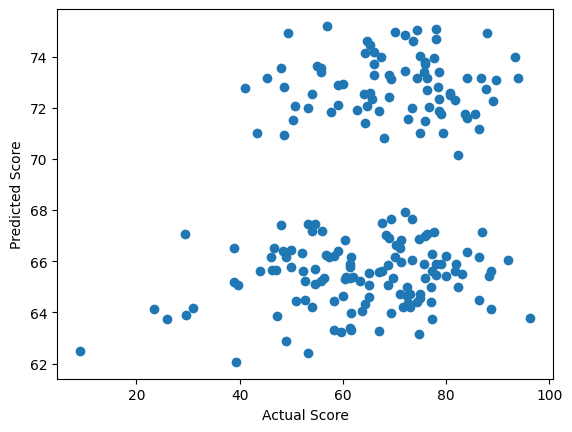

In [59]:
y_pred = model.predict(X_test)

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Score")
plt.ylabel("Predicted Score")
plt.show()




Visualization – Coefficient magnitude comparison

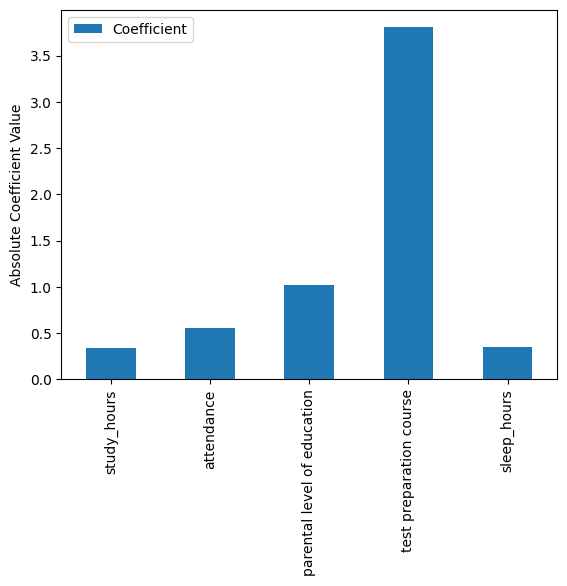

In [61]:
coefficients_abs = coefficients.abs()
coefficients_abs.plot(kind='bar')
plt.ylabel("Absolute Coefficient Value")
plt.show()


Visualization – Residual distribution

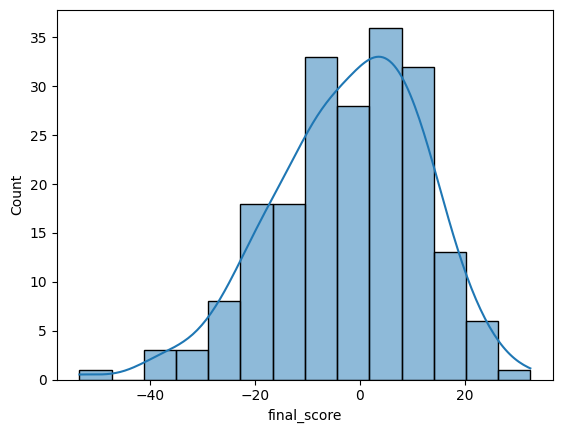

In [62]:
residuals = y_test - y_pred
sns.histplot(residuals, kde=True)
plt.show()

Scenario - 2

Load and clean the Auto MPG dataset

In [66]:
print("Roll no - 24BAD008 ")
df = pd.read_csv("auto-mpg.csv")
df.replace('?', np.nan, inplace=True)
df['horsepower'] = df['horsepower'].astype(float)
df.fillna(df.mean(numeric_only=True), inplace=True)


Roll no - 24BAD008 


Select horsepower as the independent variable

In [18]:
X = df[['horsepower']]
y = df['mpg']


Split the dataset into training and testing sets

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


Generate polynomial features (degree 2, 3, 4)

In [20]:
degrees = [2, 3, 4]


6–10. Train, predict, and evaluate Polynomial Regression models

In [22]:
from sklearn.preprocessing import PolynomialFeatures

for d in degrees:
    for d in degrees:
        poly = PolynomialFeatures(degree=d)
        X_train_poly = poly.fit_transform(X_train)
        X_test_poly = poly.transform(X_test)

        scaler = StandardScaler()
        X_train_poly = scaler.fit_transform(X_train_poly)
        X_test_poly = scaler.transform(X_test_poly)

        model = LinearRegression()
        model.fit(X_train_poly, y_train)

        y_pred = model.predict(X_test_poly)

        print(d)
        print(mean_squared_error(y_test, y_pred))
        print(np.sqrt(mean_squared_error(y_test, y_pred)))
        print(r2_score(y_test, y_pred))
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)

    scaler = StandardScaler()
    X_train_poly = scaler.fit_transform(X_train_poly)
    X_test_poly = scaler.transform(X_test_poly)

    model = LinearRegression()
    model.fit(X_train_poly, y_train)

    y_pred = model.predict(X_test_poly)

    print(d)
    print(mean_squared_error(y_test, y_pred))
    print(np.sqrt(mean_squared_error(y_test, y_pred)))
    print(r2_score(y_test, y_pred))


2
13.760855128148345
3.709562659957147
0.7440623896917427
3
13.813374257349995
3.716634802795399
0.7430855884466044
4
14.118024022829621
3.7573959097797536
0.7374194192854792
4
14.118024022829621
3.7573959097797536
0.7374194192854792
2
13.760855128148345
3.709562659957147
0.7440623896917427
3
13.813374257349995
3.716634802795399
0.7430855884466044
4
14.118024022829621
3.7573959097797536
0.7374194192854792
4
14.118024022829621
3.7573959097797536
0.7374194192854792
2
13.760855128148345
3.709562659957147
0.7440623896917427
3
13.813374257349995
3.716634802795399
0.7430855884466044
4
14.118024022829621
3.7573959097797536
0.7374194192854792
4
14.118024022829621
3.7573959097797536
0.7374194192854792


Apply Ridge regression to control overfitting

In [23]:
poly = PolynomialFeatures(degree=4)
X_poly = poly.fit_transform(X)

scaler = StandardScaler()
X_poly = scaler.fit_transform(X_poly)

ridge = Ridge(alpha=1.0)
ridge.fit(X_poly, y)


,alpha,1.0
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


Visualization – Polynomial curve fitting

c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


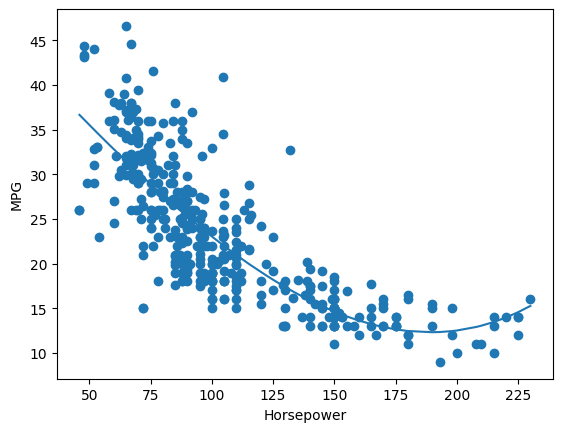

In [24]:
X_sorted = np.sort(X.values, axis=0)
X_poly_sorted = poly.transform(X_sorted)
X_poly_sorted = scaler.transform(X_poly_sorted)

y_curve = ridge.predict(X_poly_sorted)

plt.scatter(X, y)
plt.plot(X_sorted, y_curve)
plt.xlabel("Horsepower")
plt.ylabel("MPG")
plt.show()
